# Análisis Univariado: Histórico de Compras
En esta libreta se realiza el análisis exploratorio univariado del historial de compras (`Histórico_Compras`), analizando las variables clave: `fecha`, `nombre_articulo` y `unidades`.

### Cargar librerías y datos

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Cargar la hoja 'Histórico_Compras'
df_Compras = pd.read_excel('Datos_CLV_2026_Tec_v2.xlsx', sheet_name='Histórico_Compras')

# Inspección inicial
print(f"Dimensiones del DataFrame: {df_Compras.shape}")
df_Compras.head()

Dimensiones del DataFrame: (9186, 8)


,folio,fecha,articulo_id,clave_articulo,nombre_articulo,unidades,precio_unitario,precio_total_neto
0,C1,2021-03-18T00:00:00Z,82369,179212,JAEGER SPINDLE MOTION,1,77289.5600,77289.56
1,C2,2021-03-30T00:00:00Z,83401,AR175,REPL BLOWER 120V INFINITY,1,4008.3300,4008.33
2,C2,2021-03-30T00:00:00Z,83404,AR176,REPL BLOWER 230V INFINITY,1,4008.3300,4008.33
3,C2,2021-03-30T00:00:00Z,83407,AG205-5,FILTER BAGS YELLOW F205 5/BX,50,2111.9158,105595.79
4,C2,2021-03-30T00:00:00Z,83424,1-0052-0014,IVAC 2.B TWIN INFINITY 120V,1,37920.5900,37920.59


In [10]:
valores_nulos1=df_Compras.isnull().sum()
print('---Valores Nulos en Compras---')
print(valores_nulos1)

---Valores Nulos en Compras---
folio                0
fecha                0
articulo_id          0
clave_articulo       0
nombre_articulo      0
unidades             0
precio_unitario      0
precio_total_neto    0
dtype: int64


<Figure size 1500x800 with 0 Axes>

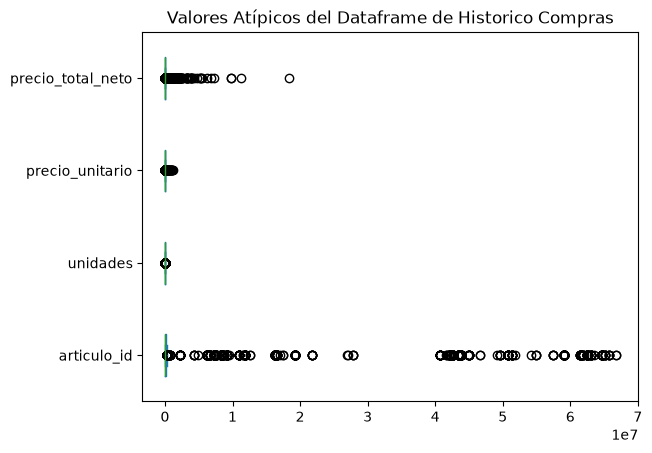

In [11]:
#Realizamos diagrama de caja o bigote de cada columna del dataframe de compras
fig = plt.figure(figsize =(15, 8))
df_Compras.plot(kind='box', vert=False)
plt.title("Valores Atípicos del Dataframe de Historico Compras")
plt.show() #dibujamos el diagrama

## 1. Análisis Univariado: Variable `fecha`
Revisión temporal del histórico de compras desde 2021 hasta 2026.

In [2]:
# Asegurar tipo datetime
df_Compras['fecha'] = pd.to_datetime(df_Compras['fecha'])

# Tabla de resumen general de fechas
resumen_fecha = pd.DataFrame({
    'Métrica': [
        'Total de registros',
        'Valores nulos',
        'Fecha mínima',
        'Fecha máxima',
        'Días únicos con compras',
        'Rango total (días)'
    ],
    'Valor': [
        f"{len(df_Compras):,}",
        f"{df_Compras['fecha'].isnull().sum()}",
        df_Compras['fecha'].min().strftime('%Y-%m-%d'),
        df_Compras['fecha'].max().strftime('%Y-%m-%d'),
        f"{df_Compras['fecha'].dt.date.nunique():,}",
        f"{(df_Compras['fecha'].max() - df_Compras['fecha'].min()).days:,} días (~5.5 años)"
    ]
})

resumen_fecha

,Métrica,Valor
0,Total de registros,"9,186"
1,Valores nulos,0
2,Fecha mínima,2021-03-18
3,Fecha máxima,2026-09-03
4,Días únicos con compras,402
5,Rango total (días),"1,995 días (~5.5 años)"


### 1.1. Distribución y Frecuencias por Año

--- TABLA DE FRECUENCIAS POR AÑO ---


,Año,Frecuencia_Absoluta,Porcentaje (%),Porcentaje_Acumulado (%)
0,2021,1650,17.96,17.96
1,2022,1378,15.00,32.96
2,2023,1731,18.84,51.80
3,2024,1214,13.22,65.02
4,2025,1912,20.81,85.83
5,2026,1301,14.16,99.99


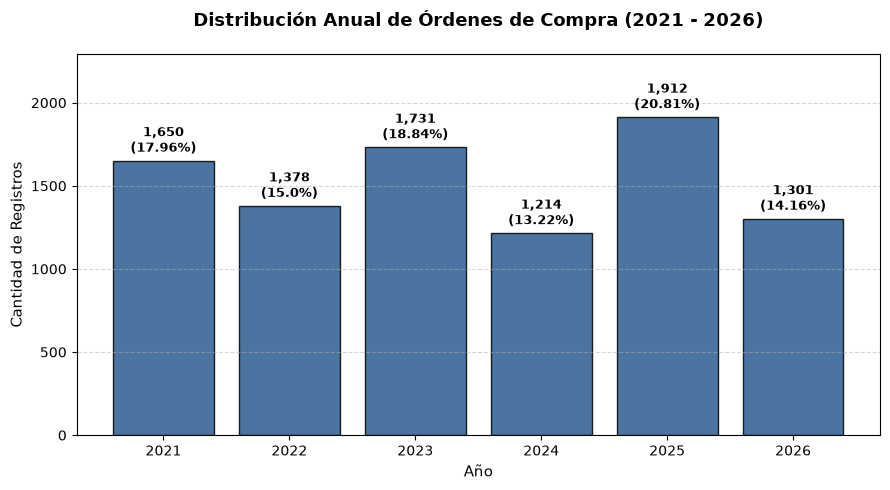

In [3]:
# Tabla de Frecuencias por Año
tabla_anio = df_Compras['fecha'].dt.year.value_counts().sort_index().reset_index()
tabla_anio.columns = ['Año', 'Frecuencia_Absoluta']
tabla_anio['Porcentaje (%)'] = (tabla_anio['Frecuencia_Absoluta'] / len(df_Compras) * 100).round(2)
tabla_anio['Porcentaje_Acumulado (%)'] = tabla_anio['Porcentaje (%)'].cumsum().round(2)

print("--- TABLA DE FRECUENCIAS POR AÑO ---")
display(tabla_anio)

# Gráfica de Barras por Año
plt.figure(figsize=(9, 5))
barras = plt.bar(
    tabla_anio['Año'].astype(str), 
    tabla_anio['Frecuencia_Absoluta'], 
    color='#2b5c8f', 
    edgecolor='black', 
    alpha=0.85
)

for barra, pct in zip(barras, tabla_anio['Porcentaje (%)']):
    yval = barra.get_height()
    plt.text(
        barra.get_x() + barra.get_width() / 2, 
        yval + 30, 
        f'{int(yval):,}\n({pct}%)', 
        ha='center', 
        va='bottom', 
        fontsize=9, 
        fontweight='bold'
    )

plt.title('Distribución Anual de Órdenes de Compra (2021 - 2026)', fontsize=13, fontweight='bold', pad=20)
plt.xlabel('Año', fontsize=11)
plt.ylabel('Cantidad de Registros', fontsize=11)
plt.ylim(0, tabla_anio['Frecuencia_Absoluta'].max() * 1.2)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### 1.2. Estacionalidad Mensual de Compras (Enero a Diciembre)

--- TABLA DE ESTACIONALIDAD MENSUAL ---


,Num_Mes,Mes,Frecuencia_Absoluta,Porcentaje (%)
0,1,Enero,1359,14.79
1,2,Febrero,360,3.92
2,3,Marzo,770,8.38
3,4,Abril,1002,10.91
4,5,Mayo,737,8.02
5,6,Junio,471,5.13
6,7,Julio,407,4.43
7,8,Agosto,685,7.46
8,9,Septiembre,1492,16.24
9,10,Octubre,841,9.16


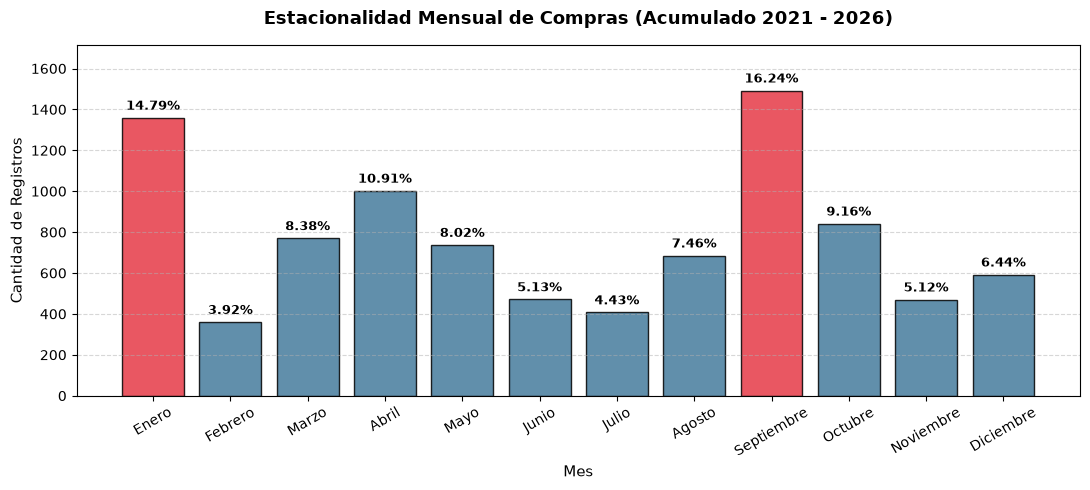

In [4]:
# Mapeo y Tabla de Frecuencias por Mes
meses = {1:'Enero', 2:'Febrero', 3:'Marzo', 4:'Abril', 5:'Mayo', 6:'Junio',
         7:'Julio', 8:'Agosto', 9:'Septiembre', 10:'Octubre', 11:'Noviembre', 12:'Diciembre'}

tabla_mes = df_Compras['fecha'].dt.month.value_counts().sort_index().reset_index()
tabla_mes.columns = ['Num_Mes', 'Frecuencia_Absoluta']
tabla_mes['Mes'] = tabla_mes['Num_Mes'].map(meses)
tabla_mes['Porcentaje (%)'] = (tabla_mes['Frecuencia_Absoluta'] / len(df_Compras) * 100).round(2)
tabla_mes = tabla_mes[['Num_Mes', 'Mes', 'Frecuencia_Absoluta', 'Porcentaje (%)']]

print("--- TABLA DE ESTACIONALIDAD MENSUAL ---")
display(tabla_mes)

# Gráfica de Barras por Mes
plt.figure(figsize=(11, 5))
colores_mes = ['#e63946' if m in ['Septiembre', 'Enero'] else '#457b9d' for m in tabla_mes['Mes']]

barras_mes = plt.bar(
    tabla_mes['Mes'], 
    tabla_mes['Frecuencia_Absoluta'], 
    color=colores_mes, 
    edgecolor='black', 
    alpha=0.85
)

for b, pct in zip(barras_mes, tabla_mes['Porcentaje (%)']):
    plt.text(
        b.get_x() + b.get_width() / 2, 
        b.get_height() + 25, 
        f'{pct}%', 
        ha='center', 
        va='bottom', 
        fontsize=9, 
        fontweight='bold'
    )

plt.title('Estacionalidad Mensual de Compras (Acumulado 2021 - 2026)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Mes', fontsize=11)
plt.ylabel('Cantidad de Registros', fontsize=11)
plt.xticks(rotation=30)
plt.ylim(0, tabla_mes['Frecuencia_Absoluta'].max() * 1.15)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 2. Análisis Univariado: Variable `nombre_articulo`
Análisis de los artículos más frecuentes y volumen de compras.

In [5]:
# Tabla de Frecuencias por Artículo
Tabla_freq_articulos = (
    df_Compras.groupby(['articulo_id', 'nombre_articulo'])
    .size()
    .reset_index(name='frecuencia_registros')
    .sort_values('frecuencia_registros', ascending=False)
)

print(f"Total de artículos únicos catalogados en compras: {df_Compras['nombre_articulo'].nunique():,}")
print("\n--- TOP 15 ARTÍCULOS MÁS REGISTRADOS EN COMPRAS ---")
display(Tabla_freq_articulos.head(15))

Total de artículos únicos catalogados en compras: 3,698

--- TOP 15 ARTÍCULOS MÁS REGISTRADOS EN COMPRAS ---


,articulo_id,nombre_articulo,frecuencia_registros
2204,114072,LAPTOP G,35
81,4232,FRESA ROTO RFID 2.5 ZI DM,26
1933,92543,CERAMILL MATCH 2 CAM DONGLE,25
83,4238,FRESA ROTO RFID 0.6 ZI DM,24
1762,84025,MEDIT INTRA ORAL SCANNER I700,23
82,4235,FRESA ROTO RFID 1.0 ZI DM,23
84,4241,FRESA ROTO RFID 0.3 ZI,22
348,5804,CAMEO PRESS INGOT BOX HT A2,22
1929,92435,FRESA ROTO RFID 1.0 SC DM,21
353,5819,CAMEO PRESS INGOT BOX LT A2,19


### 2.1. Gráfica de Barras: Top 10 Artículos con Mayor Frecuencia de Compra

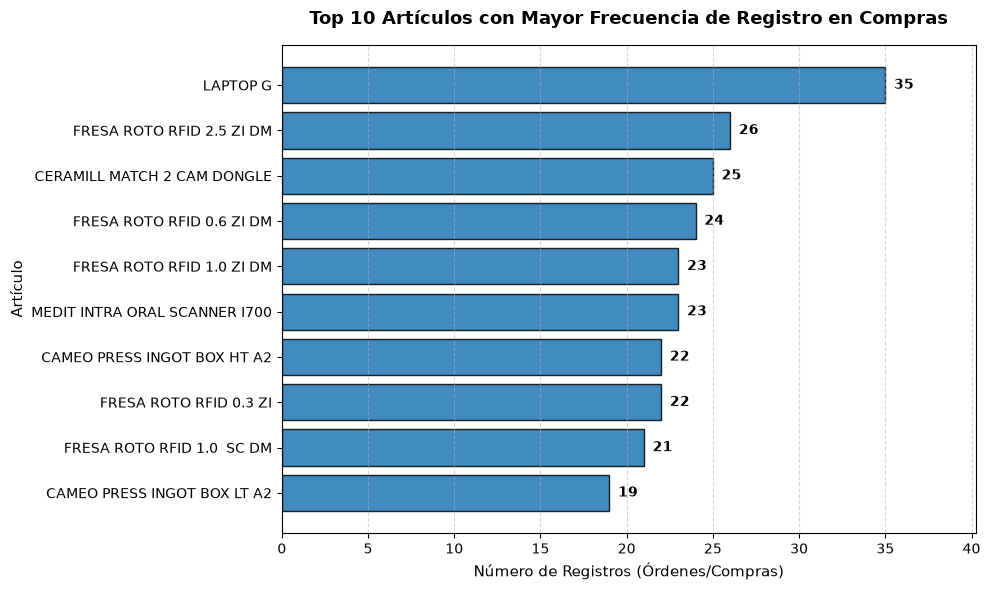

In [6]:
top10_registros = Tabla_freq_articulos.head(10).sort_values('frecuencia_registros', ascending=True)

plt.figure(figsize=(10, 6))
barras = plt.barh(
    top10_registros['nombre_articulo'], 
    top10_registros['frecuencia_registros'], 
    color='#1f77b4', 
    edgecolor='black', 
    alpha=0.85
)

for b in barras:
    plt.text(
        b.get_width() + 0.5, 
        b.get_y() + b.get_height()/2, 
        f'{int(b.get_width())}', 
        va='center', 
        fontsize=10, 
        fontweight='bold'
    )

plt.title('Top 10 Artículos con Mayor Frecuencia de Registro en Compras', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Número de Registros (Órdenes/Compras)', fontsize=11)
plt.ylabel('Artículo', fontsize=11)
plt.xlim(0, top10_registros['frecuencia_registros'].max() * 1.15)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### 2.2. Top 10 Artículos por Unidades Totales Compradas

In [7]:
top_unidades = (
    df_Compras.groupby(['articulo_id', 'nombre_articulo'])['unidades']
    .sum()
    .reset_index()
    .sort_values('unidades', ascending=False)
)

print("--- TOP 10 ARTÍCULOS POR TOTAL DE PIEZAS/UNIDADES COMPRADAS ---")
display(top_unidades.head(10))

--- TOP 10 ARTÍCULOS POR TOTAL DE PIEZAS/UNIDADES COMPRADAS ---


,articulo_id,nombre_articulo,unidades
783,7973,MFT PU31 2M2,8455
793,8003,MFT PU33 2M2,7475
754,7883,MFT PL31 2M2,6766
348,5804,CAMEO PRESS INGOT BOX HT A2,6400
764,7913,MFT PL33 2M2,5988
82,4235,FRESA ROTO RFID 1.0 ZI DM,5579
353,5819,CAMEO PRESS INGOT BOX LT A2,5510
81,4232,FRESA ROTO RFID 2.5 ZI DM,5493
347,5801,CAMEO PRESS INGOT BOX HT A1,5460
60,3872,S&S SPEEDVEST 20 X 160G + 750ML,5020


## 3. Análisis Univariado: Variable `unidades`
Evaluación de la distribución de cantidades compradas por orden.

In [8]:
print("--- Resumen Estadístico de 'unidades' ---")
stats_unidades = df_Compras['unidades'].describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
display(stats_unidades.to_frame())

--- Resumen Estadístico de 'unidades' ---


,unidades
count,9186.000000
mean,47.484651
std,116.767525
min,1.000000
25%,5.000000
50%,10.000000
75%,38.000000
90%,120.000000
95%,230.000000
99%,540.000000


### 3.1. Visualización Combinada (Boxplot + Histograma)

/var/folders/19/xs2jtz9n4qj8f7ln7m64dzjc0000gn/T/ipykernel_73991/1348733432.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax_box.boxplot(df_Compras['unidades'], vert=False, patch_artist=True,


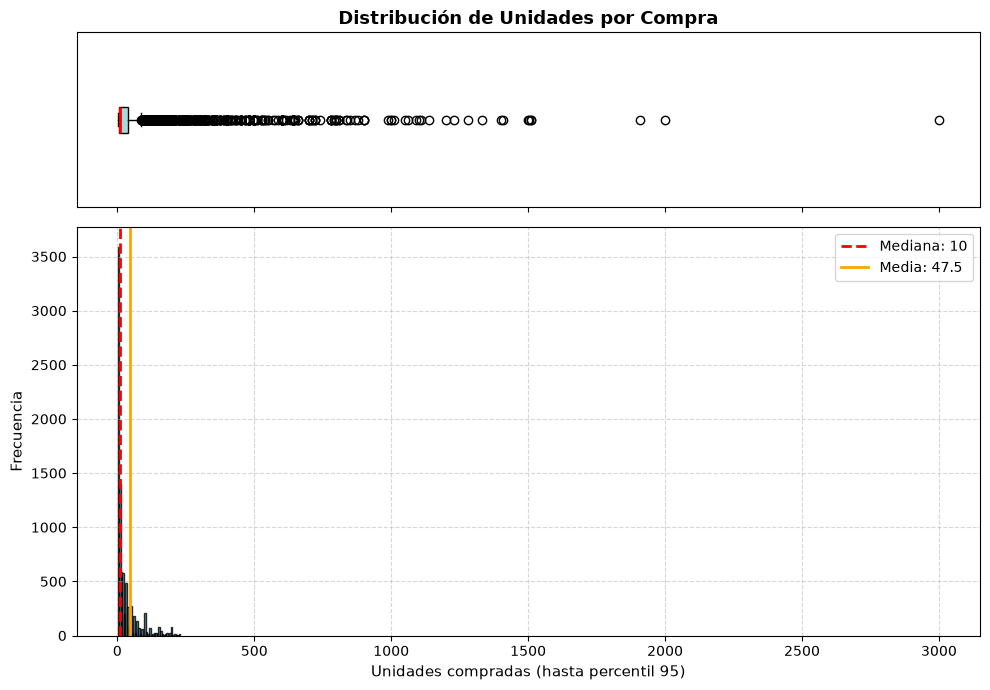

In [9]:
fig, (ax_box, ax_hist) = plt.subplots(2, 1, figsize=(10, 7), sharex=True, gridspec_kw={'height_ratios': [0.3, 0.7]})

# Boxplot
ax_box.boxplot(df_Compras['unidades'], vert=False, patch_artist=True,
               boxprops=dict(facecolor='#a8dadc', color='black'),
               medianprops=dict(color='red', linewidth=2))
ax_box.set_title('Distribución de Unidades por Compra', fontsize=13, fontweight='bold')
ax_box.set_yticks([])

# Histograma (acotado al percentil 95 para observar el cuerpo principal)
p95 = df_Compras['unidades'].quantile(0.95)
ax_hist.hist(df_Compras['unidades'], bins=40, range=(1, p95), color='#457b9d', edgecolor='black', alpha=0.8)
ax_hist.axvline(df_Compras['unidades'].median(), color='red', linestyle='--', linewidth=2, label=f"Mediana: {df_Compras['unidades'].median():.0f}")
ax_hist.axvline(df_Compras['unidades'].mean(), color='orange', linestyle='-', linewidth=2, label=f"Media: {df_Compras['unidades'].mean():.1f}")
ax_hist.set_xlabel('Unidades compradas (hasta percentil 95)', fontsize=11)
ax_hist.set_ylabel('Frecuencia', fontsize=11)
ax_hist.legend()
ax_hist.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()